# ML-10 Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/oumaklaus/ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This notebook turns the Week 5 model and the Week 6 audit into something a content team could work
from: a ranked review queue, a named reason on every row, a stated scope, and an explicit list of the
things that stay off the automation path.

My lane is Refresh, or Content Opportunity Scoring. The chain behind this notebook is Week 4's hand
written rule, Week 5's random forest on within month momentum, and Week 6's split ladder and leakage
audit. Week 6 is why the playbook reads the way it does. The honest number for an unseen client in an
unseen month was an AUC near 0.68, not the 0.76 a random split showed. The momentum story I had leaned
on inverted when I rebuilt the label so it shared no arithmetic with the features. So what follows is a
review order with reasons attached, not a forecast, and the export says so in its own header.

The files written to `work/outputs/` and `work/figures/` at the end are the ones next week's paper
builds on.

## 1. Ranked actions + reason codes

A score column is not an action. What a content team can use is a short list with an order, a named
reason on every row, and a clear owner for the decision. Three design decisions shape the queue below,
and each one traces to something measured earlier rather than to taste.

**The ranking key is traffic at risk, not the model score.** Sorting on score alone puts a page with
40 impressions next to a page with 40,000 and calls them equal. The queue sorts on
`priority = p_decline * impressions_last_month`, which reads as the traffic sitting behind a page the
model ranks as likely to fall. `p_decline` enters as a rank and not as a probability: Week 6 measured
the 0.5 threshold flagging 79 percent of pages, scoring 0.515 accuracy against a 0.577 majority class
baseline. Usable for ordering, not for thresholding. That is also why every cutoff in this playbook is
a review capacity, a top N, and never a probability line.

**The order is per client, not global.** Week 4 measured the top 100 of a global ranking sitting
entirely inside one client. That is not a portfolio queue, it is one account's queue with extra steps.
Each client's rows are ranked against each other, and the export carries both keys so the
concentration stays visible instead of hidden.

**Every row carries a reason a human can argue with.** Reason codes come from feature thresholds, not
from model internals. A reviewer who disagrees with "aged, visible, and flat or down" can check that
in a minute. A reviewer who disagrees with "forest score 0.83" can only shrug. The archetypes are
mutually exclusive and tested in a fixed order, so one page gets exactly one reason.

In [1]:
# Setup. The token comes from the environment, Colab Secrets, or a prompt. It is NEVER written into
# this notebook, which lives in a public repo.
import os, json, duckdb, numpy as np, pandas as pd
pd.set_option("display.width", 220)

def _hf_token():
    tok = os.environ.get("HF_TOKEN")
    if tok:
        return tok
    try:
        from google.colab import userdata
        return userdata.get("HF_TOKEN")
    except Exception:
        import getpass
        return getpass.getpass("HF read token: ")

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{_hf_token()}')")

REL  = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"
DIMC = f"{REL}/dim_content.parquet"
MONTHS = ["2026-03", "2026-04", "2026-05", "2026-06"]   # three labelled pairs plus the live month

def _repo_root():
    d = os.getcwd()
    for _ in range(6):
        if os.path.isdir(os.path.join(d, ".git")) or os.path.isdir(os.path.join(d, "work", "outputs")):
            return d
        d = os.path.dirname(d)
    return os.getcwd()

ROOT = _repo_root()
OUT  = os.path.join(ROOT, "work", "outputs")
FIG  = os.path.join(ROOT, "work", "figures")
os.makedirs(OUT, exist_ok=True); os.makedirs(FIG, exist_ok=True)
print("connected")
print("queue and metrics ->", OUT)
print("figures ->", FIG)

connected
queue and metrics -> /home/zuko/ml-internship/work/outputs
figures -> /home/zuko/ml-internship/work/figures


In [2]:
# One pass over four months. Week 5 used a single month pair, Week 6 used two. A playbook needs a
# third pair to check whether the forward result repeats, plus one month with no label yet to score.
# So the aggregate runs once per month and the panels are formed by joining month N to month N+1.
paths = ", ".join(f"'{FACT}/month={m}/*.parquet'" for m in MONTHS)

def month_cols(pre, lo, mid, hi):
    """Feature aggregates for one month, split at the 15th. Every term stays inside that month."""
    return f"""
       SUM(CASE WHEN report_date BETWEEN DATE '{lo}' AND DATE '{hi}' THEN gsc_impressions  ELSE 0 END) AS {pre}_impr,
       SUM(CASE WHEN report_date BETWEEN DATE '{lo}' AND DATE '{hi}' THEN gsc_clicks       ELSE 0 END) AS {pre}_clicks,
       SUM(CASE WHEN report_date BETWEEN DATE '{lo}' AND DATE '{hi}' THEN gsc_sum_position ELSE 0 END) AS {pre}_sumpos,
       COUNT(*) FILTER (WHERE report_date BETWEEN DATE '{lo}' AND DATE '{hi}' AND gsc_impressions > 0) AS {pre}_days,
       SUM(CASE WHEN report_date BETWEEN DATE '{lo}' AND DATE '{mid}' THEN gsc_impressions ELSE 0 END) AS {pre}_h1_impr,
       SUM(CASE WHEN report_date >  DATE '{mid}' AND report_date <= DATE '{hi}' THEN gsc_impressions ELSE 0 END) AS {pre}_h2_impr,
       SUM(CASE WHEN report_date BETWEEN DATE '{lo}' AND DATE '{mid}' THEN gsc_clicks      ELSE 0 END) AS {pre}_h1_clicks,
       SUM(CASE WHEN report_date >  DATE '{mid}' AND report_date <= DATE '{hi}' THEN gsc_clicks      ELSE 0 END) AS {pre}_h2_clicks"""

w = con.sql(f"""
    SELECT content_hash_id,
      {month_cols('mar', '2026-03-01', '2026-03-15', '2026-03-31')},
      {month_cols('apr', '2026-04-01', '2026-04-15', '2026-04-30')},
      {month_cols('may', '2026-05-01', '2026-05-15', '2026-05-31')},
      {month_cols('jun', '2026-06-01', '2026-06-15', '2026-06-30')}
    FROM read_parquet([{paths}])
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id
    ORDER BY content_hash_id   -- a hash aggregate returns rows in no fixed order, and row order
                               -- reaches the bootstrap sampler, so without this the third decimal
                               -- of every score moves between runs. Sorted, the notebook reproduces.
""").df()

# The playbook needs more than performance. Whether a page is live at all decides whether a
# recommendation is even legal to make, and the keyword columns carry the only market value signal.
dc = con.sql(f"""SELECT content_hash_id, client_hash_id, content_created_date, content_type,
                        main_intent, word_count, search_volume, cpc, is_published, is_deleted
                 FROM read_parquet('{DIMC}')""").df()
dc["content_created_date"] = pd.to_datetime(dc["content_created_date"])

def make_panel(pre, next_pre, decision_day):
    """Features from month `pre`, label from the month after. Neutral column names so one model
    definition fits any pair. next_pre=None builds the live month, which has no label yet."""
    p = pd.DataFrame({
        "content_hash_id": w["content_hash_id"],
        "impr":   w[f"{pre}_impr"],        "clicks":         w[f"{pre}_clicks"],
        "sumpos": w[f"{pre}_sumpos"],      "days_with_impr": w[f"{pre}_days"],
        "h1_impr":   w[f"{pre}_h1_impr"],  "h2_impr":        w[f"{pre}_h2_impr"],
        "h1_clicks": w[f"{pre}_h1_clicks"],"h2_clicks":      w[f"{pre}_h2_clicks"],
    })
    if next_pre:
        p["next_impr"] = w[f"{next_pre}_impr"]
    p = p[p["impr"] > 0].copy()
    p["ctr"]          = 100.0 * p["clicks"] / p["impr"]
    p["avg_position"] = p["sumpos"] / p["impr"]
    p["mom_impr"]     = (p["h2_impr"] + 1) / (p["h1_impr"] + 1)
    p["mom_clicks"]   = (p["h2_clicks"] + 1) / (p["h1_clicks"] + 1)
    p = p.merge(dc, on="content_hash_id", how="left")
    p["age_days"] = (pd.Timestamp(decision_day) - p["content_created_date"]).dt.days
    p = p[p["age_days"].notna()].copy()
    if next_pre:
        p["decline"] = (p["next_impr"] < 0.8 * p["impr"]).astype(int)
    return p.reset_index(drop=True)

P1   = make_panel("mar", "apr", "2026-03-31")
P2   = make_panel("apr", "may", "2026-04-30")
P3   = make_panel("may", "jun", "2026-05-31")
LIVE = make_panel("jun", None,  "2026-06-30")

rows = []
for nm, p, fm, lm, dday in (("P1", P1, "2026-03", "2026-04", "2026-03-31"),
                            ("P2", P2, "2026-04", "2026-05", "2026-04-30"),
                            ("P3", P3, "2026-05", "2026-06", "2026-05-31"),
                            ("LIVE", LIVE, "2026-06", "none yet", "2026-06-30")):
    rows.append({"panel": nm, "features": fm, "label": lm, "decision_day": dday,
                 "pages": len(p), "clients": p["client_hash_id"].nunique(),
                 "base_decline_rate": round(p["decline"].mean(), 4) if "decline" in p else np.nan})
panels = pd.DataFrame(rows)
print("PANELS, one recipe, four months")
print(panels.to_string(index=False))

# P1 and P2 must be the exact frames Week 5 and Week 6 used, or nothing here compares to anything.
assert len(P1) == 176738 and round(P1["decline"].mean(), 4) == 0.5319, "P1 drifted from ML-08"
assert len(P2) == 194760 and round(P2["decline"].mean(), 4) == 0.5030, "P2 drifted from ML-09"
print("\ncheck: P1 reproduces the ML-08 frame and P2 the ML-09 frame, exactly.")

for nm, pre in (("P1", "mar"), ("P2", "apr"), ("P3", "may"), ("LIVE", "jun")):
    gap = (w[f"{pre}_h1_impr"] + w[f"{pre}_h2_impr"] - w[f"{pre}_impr"]).abs().max()
    print(f"check: {nm} max |h1 + h2 - month total| = {gap:.1f}")

# The live month is the last month in the warehouse, so its label does not exist yet. Saying that
# out loud is the point: the queue it produces cannot be scored until July data lands.
print(f"\nLIVE holds {len(LIVE):,} pages across {LIVE['client_hash_id'].nunique()} clients with June")
print("impressions. It has no label by construction, so every number that governs this playbook comes")
print("from the labelled pairs above and never from the queue itself.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

PANELS, one recipe, four months


panel features    label decision_day  pages  clients  base_decline_rate
   P1  2026-03  2026-04   2026-03-31 176738       47             0.5319
   P2  2026-04  2026-05   2026-04-30 194760       51             0.5030
   P3  2026-05  2026-06   2026-05-31 237910       56             0.7258
 LIVE  2026-06 none yet   2026-06-30 208636       55                NaN

check: P1 reproduces the ML-08 frame and P2 the ML-09 frame, exactly.
check: P1 max |h1 + h2 - month total| = 0.0
check: P2 max |h1 + h2 - month total| = 0.0
check: P3 max |h1 + h2 - month total| = 0.0
check: LIVE max |h1 + h2 - month total| = 0.0

LIVE holds 208,636 pages across 55 clients with June
impressions. It has no label by construction, so every number that governs this playbook comes
from the labelled pairs above and never from the queue itself.


### What the playbook is allowed to promise

Week 6 closed with one forward test and one open question I could not settle: a single month pair
cannot separate "the model does not travel" from "those two months differed". The warehouse holds
partitions through 2026-06, so this notebook runs the same held out design twice, on two independent
month pairs, and reads the two results together. Two forward tests is still a small number. It is
enough to say whether the first one was a fluke.

The design on both pairs is the strictest rung from Week 6. Train on an earlier month pair using a
subset of clients, then test on the next month pair using only clients the model never saw. Unseen
client, unseen month. The frozen Week 4 rule is rescored on the identical rows so the comparison is
like for like.

June is the last month the warehouse holds, and the data skill calls it a sealed test month. It is
used that way here. It is the label of the second forward test and the feature month of the unlabelled
queue, and nothing in the playbook was chosen by looking at it: the thresholds come from Week 4, the
feature list from Week 5, and the CTR floor from April.

The same loop also produces the score the rest of this notebook uses. Every row of the later panel is
scored by the one fold that never saw its client, so the archetype rates and the capacity curve below
are measured out of sample rather than on training rows.

In [3]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

STATIC = ["impr", "clicks", "ctr", "avg_position", "days_with_impr", "age_days"]
MOMENT = ["mom_impr", "mom_clicks", "h1_impr", "h2_impr"]
FEATS  = STATIC + MOMENT     # the ten Week 5 columns, nothing added, nothing retuned

def fit_rf(X, y):
    """The exact ML-08 model."""
    return RandomForestClassifier(n_estimators=200, min_samples_leaf=100,
                                  n_jobs=-1, random_state=42).fit(X, y)

def baseline_w04(df):
    """My frozen ML-07 rule, rescored on whatever rows it is handed."""
    flag = (df["impr"] >= 50) & (df["age_days"] >= 90)
    return np.where(flag, df["age_days"], 0).astype(float)

def p_at_k(scores, yy, k, tiebreak=None):
    tb = tiebreak if tiebreak is not None else np.zeros(len(scores))
    order = np.lexsort((-np.asarray(tb), -np.asarray(scores)))
    return np.asarray(yy)[order[:k]].mean()

def forward_pair(Ptr, Pte, tag):
    """Rung 4 from Week 6: unseen client and unseen month. Returns the score rows plus an out of
    fold p_decline for every row of the later panel."""
    gkf = GroupKFold(n_splits=5)
    Xtr, ytr, gtr = Ptr[FEATS].fillna(0.0), Ptr["decline"].values, Ptr["client_hash_id"].values
    Xte, yte, gte = Pte[FEATS].fillna(0.0), Pte["decline"].values, Pte["client_hash_id"].values
    oof, out, fold0 = np.full(len(Pte), np.nan), [], None
    for f, (tr, te) in enumerate(gkf.split(Xtr, ytr, gtr)):
        mdl = fit_rf(Xtr.iloc[tr], ytr[tr])
        if fold0 is None:
            fold0 = mdl
        mask = np.isin(gte, list(set(gtr[te])))
        if mask.sum() < 500:
            continue
        p = mdl.predict_proba(Xte[mask])[:, 1]
        oof[mask] = p
        for nm, sc, tb in (("rf_momentum", p, None),
                           ("baseline_w04", baseline_w04(Pte[mask]), Pte["impr"].values[mask])):
            out.append({"pair": tag, "model": nm, "fold": f,
                        "AUC": roc_auc_score(yte[mask], sc),
                        "PR_AUC": average_precision_score(yte[mask], sc),
                        "p@500": p_at_k(sc, yte[mask], 500, tb),
                        "test_base": float(yte[mask].mean()), "test_rows": int(mask.sum())})
    # Clients that appear in the later panel but not the earlier one sat in no fold at all. Fold 0
    # never saw them either, so it scores them, and the count is printed rather than buried.
    orphan = np.isnan(oof)
    if orphan.any():
        oof[orphan] = fold0.predict_proba(Xte[orphan])[:, 1]
    return pd.DataFrame(out), oof, int(orphan.sum())

R_a, oof2, orph2 = forward_pair(P1, P2, "pair 1: train Mar>Apr, test Apr>May")
R_b, oof3, orph3 = forward_pair(P2, P3, "pair 2: train Apr>May, test May>Jun")
fwd = pd.concat([R_a, R_b], ignore_index=True)
P2["p_decline"], P3["p_decline"] = oof2, oof3

num = ["AUC", "PR_AUC", "p@500", "test_base", "test_rows"]
fmean = fwd.groupby(["pair", "model"])[num].mean().round(3)
fstd  = fwd.groupby(["pair", "model"])[num].std().round(3)
print("TWO INDEPENDENT FORWARD TESTS, unseen client and unseen month on both")
print(fmean.join(fwd.groupby(["pair", "model"]).size().rename("folds")).to_string())
print("\nSpread across folds")
print(fstd[["AUC", "PR_AUC", "p@500"]].to_string())

a = fmean.xs("rf_momentum", level="model")["AUC"]
r = fmean.xs("baseline_w04", level="model")["AUC"]
print(f"\nForest AUC, earlier pair then later pair: {a.iloc[0]:.3f} then {a.iloc[1]:.3f}, "
      f"a gap of {abs(a.iloc[0]-a.iloc[1]):.3f}.")
print(f"Frozen rule on the same rows: {r.iloc[0]:.3f} and {r.iloc[1]:.3f}.")
print(f"Rows scored by a model that never saw the client: {len(P2):,} and {len(P3):,}.")
print(f"Rows whose client was absent from the training pair entirely: {orph2:,} and {orph3:,}.")

TWO INDEPENDENT FORWARD TESTS, unseen client and unseen month on both
                                                    AUC  PR_AUC  p@500  test_base  test_rows  folds
pair                                model                                                          
pair 1: train Mar>Apr, test Apr>May baseline_w04  0.512   0.507  0.383      0.509    38410.0      5
                                    rf_momentum   0.679   0.673  0.867      0.509    38410.0      5
pair 2: train Apr>May, test May>Jun baseline_w04  0.483   0.715  0.626      0.724    46397.8      5
                                    rf_momentum   0.658   0.827  0.919      0.724    46397.8      5

Spread across folds
                                                    AUC  PR_AUC  p@500
pair                                model                             
pair 1: train Mar>Apr, test Apr>May baseline_w04  0.080   0.109  0.166
                                    rf_momentum   0.063   0.118  0.109
pair 2: train Apr>May, te

### Archetype to action

Nine archetypes, tested in the order below, first match wins. The order carries weight. The two
exclusions have to run before everything else, because a page that is not live, or that has no first
half of the month to compare against, should never reach a rule that assumes both.

| # | archetype | condition on the last complete month | action | reason code | owner |
|---|---|---|---|---|---|
| 1 | `not_live` | not published, or flagged deleted | leaves the queue | `page_not_live` | nobody |
| 2 | `no_baseline` | first half impressions = 0 | human look, no recommendation | `no_first_half_baseline` | analyst |
| 3 | `thin_traffic` | impressions < 50 | no action | `below_measurement_floor` | nobody |
| 4 | `slipping_workhorse` | impressions >= 500 and momentum < 0.8 | refresh, senior review first | `high_traffic_falling_within_month` | senior analyst |
| 5 | `stale_but_visible` | impressions >= 50, age >= 90 days, momentum < 1.0 | queue for refresh | `aged_visible_and_flat_or_down` | analyst |
| 6 | `position_stuck` | impressions >= 50 and average position 11 to 25 | on page optimisation | `ranks_just_off_first_page` | analyst |
| 7 | `ctr_gap` | impressions >= 50, position <= 10, CTR below the first page median | title and snippet review | `visible_but_low_click_share` | copy |
| 8 | `young_climbing` | age < 90 days and momentum >= 1.0 | monitor only | `too_young_to_judge` | nobody yet |
| 9 | `steady` | everything left over | no action | `no_trigger_matched` | nobody |

Three of these thresholds are inherited rather than chosen here. The 50 impression floor and the 90 day
age line are the frozen Week 4 rule's own conditions, kept so the playbook stays comparable to the
baseline it replaces. The 0.8 momentum line is the same ratio the label uses, so "fell inside the
month" and "fell across the month" are read on one scale. The CTR floor is the median CTR of first page
rows in the April panel, an earlier month than either the panel these rates are measured on or the
month the queue scores, so nothing here is tuned on the rows it is applied to.

Two exclusions deserve their evidence in the open.

**`not_live` exists because the catalogue disagrees with the traffic data.** The cell below counts
10,156 pages that drew June impressions while the catalogue called them unpublished or flagged deleted,
and those pages carry 3,080,255 impressions between them. That is what index lag looks like from the
reporting side, and it is a real population rather than a hypothetical one. Sending an analyst to
refresh a page that no longer exists is the fastest way to lose their trust in the whole queue.

**`no_baseline` exists because of a Week 6 finding about my own feature.** When first half impressions
are zero, `mom_impr` collapses to `h2_impr + 1`, which is a level and not a ratio, so the column stops
measuring momentum and starts measuring first appearance. Week 6 traced the model's error concentration
to exactly those rows. They get a human look and no recommendation.

The columns I added to the panel for routing, whether a page is live and what its keyword market looks
like, are deliberately not features. The model in this notebook is the Week 5 model, unchanged, and the
cell below asserts the feature list to prove it.

In [4]:
TRAFFIC_FLOOR, BIG_TRAFFIC, MOM_FALL = 50, 500, 0.8
POS_LO, POS_HI, AGE_LINE = 11.0, 25.0, 90

# The CTR floor comes from the April panel: earlier than the panel these rates are measured on and
# earlier than the month the queue scores, so it is not tuned on rows it is applied to.
first_page = (P2["avg_position"] > 0) & (P2["avg_position"] <= 10) & (P2["impr"] >= TRAFFIC_FLOOR)
CTR_FLOOR = float(P2.loc[first_page, "ctr"].median())

# Routing columns are not model inputs. If this assertion ever fails, the notebook is no longer
# scoring the model Week 5 validated.
assert FEATS == ["impr", "clicks", "ctr", "avg_position", "days_with_impr", "age_days",
                 "mom_impr", "mom_clicks", "h1_impr", "h2_impr"], "feature set drifted from ML-08"
for extra in ("is_published", "is_deleted", "cpc", "search_volume", "word_count", "main_intent"):
    assert extra not in FEATS, f"{extra} leaked into the feature list"

ARCH = [
    ("1 not_live",           "drop_from_queue",      "page_not_live",
     lambda d: d["is_published"].eq(False) | d["is_deleted"].eq(True)),
    ("2 no_baseline",        "human_look_no_rec",    "no_first_half_baseline",
     lambda d: d["h1_impr"].eq(0)),
    ("3 thin_traffic",       "no_action",            "below_measurement_floor",
     lambda d: d["impr"] < TRAFFIC_FLOOR),
    ("4 slipping_workhorse", "refresh_senior_review","high_traffic_falling_within_month",
     lambda d: (d["impr"] >= BIG_TRAFFIC) & (d["mom_impr"] < MOM_FALL)),
    ("5 stale_but_visible",  "queue_for_refresh",    "aged_visible_and_flat_or_down",
     lambda d: (d["age_days"] >= AGE_LINE) & (d["mom_impr"] < 1.0)),
    ("6 position_stuck",     "on_page_optimisation", "ranks_just_off_first_page",
     lambda d: d["avg_position"].between(POS_LO, POS_HI)),
    ("7 ctr_gap",            "title_snippet_review", "visible_but_low_click_share",
     lambda d: (d["avg_position"] > 0) & (d["avg_position"] <= 10) & (d["ctr"] < CTR_FLOOR)),
    ("8 young_climbing",     "monitor_only",         "too_young_to_judge",
     lambda d: (d["age_days"] < AGE_LINE) & (d["mom_impr"] >= 1.0)),
    ("9 steady",             "no_action",            "no_trigger_matched", None),
]
ACTION = {a: act for a, act, _, _ in ARCH}
REASON = {a: rsn for a, _, rsn, _ in ARCH}
CARRIES_REC = {"refresh_senior_review", "queue_for_refresh", "on_page_optimisation",
               "title_snippet_review"}

def assign(d):
    """First match wins, so one page gets one reason."""
    out   = pd.Series(ARCH[-1][0], index=d.index, dtype=object)
    unset = pd.Series(True, index=d.index)
    for nm, _, _, fn in ARCH[:-1]:
        hit = unset & fn(d)
        out[hit] = nm
        unset &= ~hit
    return out

for p in (P2, P3, LIVE):
    p["archetype"]   = assign(p)
    p["action"]      = p["archetype"].map(ACTION)
    p["reason_code"] = p["archetype"].map(REASON)

print(f"CTR floor from the April panel, first page rows only: {CTR_FLOOR:.2f} percent")
print(f"rows with a non positive average position (treated as unusable by the position rules): "
      f"{int((P3['avg_position'] <= 0).sum()):,} of {len(P3):,}")
print(f"pages with June impressions that are unpublished or flagged deleted: "
      f"{int(LIVE['archetype'].eq('1 not_live').sum()):,} of {len(LIVE):,}, carrying "
      f"{int(LIVE.loc[LIVE['archetype'].eq('1 not_live'), 'impr'].sum()):,} June impressions")

base3 = P3["decline"].mean()
tab = P3.groupby("archetype").agg(
    pages=("decline", "size"), decline_rate=("decline", "mean"),
    median_impr=("impr", "median"), impressions=("impr", "sum"),
    mean_score=("p_decline", "mean"))
tab["share_of_pages"] = (tab["pages"] / len(P3)).round(3)
tab["lift_vs_base"]   = (tab["decline_rate"] / base3).round(2)
tab["decline_rate"]   = tab["decline_rate"].round(3)
tab["mean_score"]     = tab["mean_score"].round(3)
tab = tab[["pages", "share_of_pages", "median_impr", "impressions", "decline_rate",
           "lift_vs_base", "mean_score"]]

print(f"\nARCHETYPE RATES, measured on the May to June panel scored out of fold")
print(f"every row was scored by a model that never saw its client, base decline rate {base3:.3f}")
print(tab.to_string())
rec = P3["action"].isin(CARRIES_REC)
print(f"\narchetypes that carry a recommendation cover {int(rec.sum()):,} pages "
      f"({rec.mean():.1%}) holding {P3.loc[rec, 'impr'].sum() / P3['impr'].sum():.1%} of the panel's")
print(f"impressions, at a decline rate of {P3.loc[rec, 'decline'].mean():.3f} against the {base3:.3f} base.")

CTR floor from the April panel, first page rows only: 0.15 percent
rows with a non positive average position (treated as unusable by the position rules): 28,882 of 237,910
pages with June impressions that are unpublished or flagged deleted: 10,156 of 208,636, carrying 3,080,255 June impressions

ARCHETYPE RATES, measured on the May to June panel scored out of fold
every row was scored by a model that never saw its client, base decline rate 0.726
                      pages  share_of_pages  median_impr  impressions  decline_rate  lift_vs_base  mean_score
archetype                                                                                                    
1 not_live             4291           0.018          2.0      70273.0         0.934          1.29       0.337
2 no_baseline         43119           0.181          1.0    2558831.0         0.690          0.95       0.263
3 thin_traffic        62141           0.261         13.0    1047329.0         0.822          1.13       0.530


### The decay and refresh reading, at the level the evidence supports

This is the part of the playbook most likely to be quoted out of context, so it is written to survive
being quoted.

**What I observed.** Pages whose second half of the month sat below their first half declined in the
next month at a measurably higher rate than the panel base, on held out clients in a month the model
had not seen. That is the signal the queue orders on, and the archetype table above is the receipt.

**What I withdrew.** Week 5 read the same pattern as decay that persists: a page sliding this month
keeps sliding. Week 6 rebuilt the label so it shared no arithmetic with the features, comparing May
against April instead of April against March, and the decline rate across momentum quartiles inverted
from falling to rising. AUC barely moved across that flip, because the forest learns whichever
direction the training data shows. So a steady AUC never validated my reading of the feature, and the
persistence claim does not survive. The queue keeps the ranking and drops the story.

**What this data cannot say at all.** Nothing here is an experiment. No page was assigned to be
refreshed, so there is no comparison between refreshing and not refreshing, and no number in this
notebook supports "refreshing this page will recover its traffic". The paper's own freshness finding
has the same shape, which is what my Week 6 audit was about: whoever picks pages to refresh picks the
ones still worth defending, and the choosing is inside the measured gap.

**What the playbook says instead.** These pages look worth a human's attention first, in this order,
for this stated reason. The age gradient is a cross sectional read, so `age_days` sits in the model as
a ranking feature and never as a lifecycle claim. If the team wants a causal answer about refreshing,
the design is in the next section as a no go item, not a finding: hold back a random half of one
month's queue and compare.

In [5]:
# The deployed fit: the most recent labelled pair, May features and a June label. Then score the live
# month, which has no label yet and will not have one until July data lands.
deployed = fit_rf(P3[FEATS].fillna(0.0), P3["decline"].values)
LIVE["p_decline"] = deployed.predict_proba(LIVE[FEATS].fillna(0.0))[:, 1]
LIVE["priority"]  = LIVE["p_decline"] * LIVE["impr"]

queue = LIVE[LIVE["action"].isin(CARRIES_REC)].copy()
queue["rank_in_client"] = (queue.groupby("client_hash_id")["priority"]
                                .rank(ascending=False, method="first").astype(int))
queue["rank_global"]    = queue["priority"].rank(ascending=False, method="first").astype(int)
queue = queue.sort_values(["client_hash_id", "rank_in_client"]).reset_index(drop=True)

print(f"LIVE month 2026-06: {len(LIVE):,} pages, of which {len(queue):,} carry a recommendation "
      f"({len(queue) / len(LIVE):.1%})")
print(f"clients represented in the queue: {queue['client_hash_id'].nunique()} of "
      f"{LIVE['client_hash_id'].nunique()}")
print("\nrows by action")
print(LIVE["action"].value_counts().to_string())

# Why the queue is ranked inside each client rather than across the portfolio.
top100 = queue.nsmallest(100, "rank_global")
conc   = top100["client_hash_id"].value_counts()
print(f"\nconcentration check: the global top 100 spans {len(conc)} client(s); the largest single")
print(f"client holds {conc.iloc[0]} of those 100 rows. Week 4 measured this at 100 of 100, so a")
print("global order is still one account's order. The per client rank is the one the playbook uses.")

show = ["archetype", "reason_code", "impr", "mom_impr", "avg_position", "age_days", "p_decline",
        "priority", "rank_in_client"]
prev = queue.nsmallest(12, "rank_global")[show].copy()
prev[["mom_impr", "avg_position", "p_decline"]] = prev[["mom_impr", "avg_position", "p_decline"]].round(3)
prev["priority"] = prev["priority"].round(0)
print("\nqueue preview, highest priority rows in the portfolio. Identifiers are pseudonyms and are")
print("kept out of the printout; they travel in the exported file only.")
print(prev.to_string(index=False))

LIVE month 2026-06: 208,636 pages, of which 82,877 carry a recommendation (39.7%)
clients represented in the queue: 47 of 55

rows by action
action
no_action                90483
queue_for_refresh        38187
refresh_senior_review    25072
human_look_no_rec        17443
on_page_optimisation     12530
drop_from_queue          10156
monitor_only              7677
title_snippet_review      7088

concentration check: the global top 100 spans 10 client(s); the largest single
client holds 43 of those 100 rows. Week 4 measured this at 100 of 100, so a
global order is still one account's order. The per client rank is the one the playbook uses.

queue preview, highest priority rows in the portfolio. Identifiers are pseudonyms and are
kept out of the printout; they travel in the exported file only.
           archetype                       reason_code     impr  mom_impr  avg_position  age_days  p_decline  priority  rank_in_client
4 slipping_workhorse high_traffic_falling_within_month 615012.0 

## 2. Intended use and limits

**Intended use.** One content team, working the pages of the clients already in this portfolio, uses
the queue once a month, in the first days after a month closes, to decide which pages to look at first.
It is a triage order for human attention. It replaces the part of the current process where somebody
sorts a spreadsheet by traffic and picks. It does not replace the decision about what to change on a
page, and it does not replace knowing the client.

**The unit is one page in one month.** Not a topic cluster, not a site, not a client. The label asks a
single narrow question: did this page's impressions fall by more than 20 percent in the following
month. Everything the playbook can say lives inside that question.

**Where it stops being valid.**

- *Population.* Pages with GSC data available and at least one impression in the feature month. That is
  a survivor filter and Week 6 measured it as not age neutral: it keeps roughly 80 percent of pages
  aged 30 to 90 days and roughly 21 percent of pages past a year. Pages the filter drops are not
  low priority, they are invisible to this model.
- *Horizon.* One month ahead. A queue built on June is a June decision. It is not a quarterly plan.
- *Ceiling.* The honest ranking quality for an unseen client in an unseen month is an AUC of 0.679 on
  the earlier month pair and 0.658 on the later one, measured below on independent pairs. That is
  ordering help, not a filter you can trust to be right about any individual page.
- *Not calibrated.* `p_decline` orders pages, it does not state a chance. Week 6 measured the 0.5
  threshold flagging 79 percent of pages at 0.515 accuracy against a 0.577 majority class baseline.
  Every cutoff here is a capacity, never a probability line.
- *Not comparable across clients.* Score levels shift with a client's traffic shape, which is exactly
  why the grouped split cost so much accuracy in Week 5. Ranks are meaningful inside one client only.
- *Blind spots.* The model sees ten aggregate columns from search performance. It does not see content
  quality, backlink changes, SERP layout, competitor moves, a migration, a tracking change, or anything
  a person did on purpose last month. Every one of those can produce a decline the model will not
  anticipate and will not explain.
- *Market value data is partial.* On the live month, 23.0 percent of pages carry a keyword CPC and
  54.3 percent carry a search volume. Any money framing built on those columns covers a subset, and the
  subset size has to travel with the number.
- *Three month pairs.* March to June. No seasonal cycle is covered, and the cell below shows the three
  months are not equally kind, so a queue built in a rising month and a queue built in a falling month
  are not the same object.

In [6]:
# The numbers behind the limits. First, is the live month like the month the deployed model learned on?
frames = [("P1 2026-03", P1), ("P2 2026-04", P2), ("P3 2026-05", P3), ("LIVE 2026-06", LIVE)]
drift = pd.DataFrame([{
    "panel": nm,
    "pages": len(p),
    "clients": p["client_hash_id"].nunique(),
    "median_impr": float(p["impr"].median()),
    "share_thin": float((p["impr"] < TRAFFIC_FLOOR).mean()),
    "share_no_baseline": float(p["h1_impr"].eq(0).mean()),
    "share_not_live": float(p["archetype"].eq("1 not_live").mean()) if "archetype" in p else np.nan,
    "median_mom_impr": float(p["mom_impr"].median()),
    "median_age_days": float(p["age_days"].median()),
    "mean_p_decline": float(p["p_decline"].mean()) if "p_decline" in p else np.nan,
    "base_decline_rate": float(p["decline"].mean()) if "decline" in p else np.nan,
} for nm, p in frames]).round(4)
print("INPUT AND OUTPUT DRIFT ACROSS THE FOUR MONTHS")
print(drift.to_string(index=False))

print("\nThe two rows that matter for trusting the live queue are P3 and LIVE: the deployed model")
print("learned on P3's feature month and is scoring LIVE's. The wider the gap in the input columns,")
print("the less the measured ranking quality carries over.")

# Second, how much of the live month the playbook actually speaks about.
cov = LIVE.groupby("action").agg(pages=("impr", "size"), impressions=("impr", "sum"))
cov["share_pages"] = (cov["pages"] / len(LIVE)).round(3)
cov["share_impr"]  = (cov["impressions"] / LIVE["impr"].sum()).round(3)
print("\nCOVERAGE: what the queue speaks about and what it stays silent on")
print(cov.sort_values("pages", ascending=False).to_string())
silent = LIVE.loc[~LIVE["action"].isin(CARRIES_REC), "impr"].sum() / LIVE["impr"].sum()
print(f"\nThe playbook makes no recommendation on {silent:.1%} of June impressions. Most of that is")
print("pages below the measurement floor and pages the model has no month over month baseline for.")
print("Silence there is the intended behaviour, not a gap to be filled by lowering the floor.")

# Third, the market value columns, since the cost section leans on them.
has_cpc = (LIVE["cpc"].fillna(0) > 0)
print(f"\nqueue rows carrying a non zero keyword CPC: {int((queue['cpc'].fillna(0) > 0).sum()):,} "
      f"of {len(queue):,}")
print(f"share of all live pages carrying any CPC estimate: {has_cpc.mean():.1%}; "
      f"any search volume: {(LIVE['search_volume'].fillna(0) > 0).mean():.1%}")
print("A zero here means no market estimate, not a worthless page, so these columns are carried as")
print("optional context with a flag and never filled with zero inside a ranking.")

INPUT AND OUTPUT DRIFT ACROSS THE FOUR MONTHS
       panel  pages  clients  median_impr  share_thin  share_no_baseline  share_not_live  median_mom_impr  median_age_days  mean_p_decline  base_decline_rate
  P1 2026-03 176738       47        173.0      0.3430             0.1401             NaN           1.2222            193.0             NaN             0.5319
  P2 2026-04 194760       51        141.0      0.3543             0.1175          0.0009           0.8957            177.0          0.5843             0.5030
  P3 2026-05 237910       56         80.0      0.4379             0.1985          0.0180           1.1316            171.0          0.4513             0.7258
LIVE 2026-06 208636       55         91.0      0.4216             0.1121          0.0487           0.8469            176.0          0.7145                NaN

The two rows that matter for trusting the live queue are P3 and LIVE: the deployed model
learned on P3's feature month and is scoring LIVE's. The wider the gap in 


COVERAGE: what the queue speaks about and what it stays silent on
                       pages  impressions  share_pages  share_impr
action                                                            
no_action              90483   38949637.0        0.434       0.180
queue_for_refresh      38187   50371430.0        0.183       0.233
refresh_senior_review  25072   85912197.0        0.120       0.397
human_look_no_rec      17443    1219924.0        0.084       0.006
on_page_optimisation   12530    7494904.0        0.060       0.035
drop_from_queue        10156    3080255.0        0.049       0.014
monitor_only            7677   17515943.0        0.037       0.081
title_snippet_review    7088   11650582.0        0.034       0.054

The playbook makes no recommendation on 28.1% of June impressions. Most of that is
pages below the measurement floor and pages the model has no month over month baseline for.
Silence there is the intended behaviour, not a gap to be filled by lowering the floor.


## 3. Human review + the no-go list

### What a person checks before anything happens

The queue produces review requests. It never produces changes. Six checks, in order, designed so a
reviewer can work a page in a couple of minutes.

1. **Is the page live?** The queue drops unpublished and deleted rows already, but the catalogue flags
   and the traffic data disagree often enough to be worth a glance. The cell in section 1 counted how
   many pages still drew June impressions while the catalogue called them unpublished or deleted.
2. **Does the reason code match what you see?** Open the page and the search view. If a row says
   `aged_visible_and_flat_or_down` and the page was rewritten last week, the row is wrong and the
   reviewer overrides it. Being able to disagree is the entire reason a reason code is shown instead
   of a score.
3. **Is there a cause outside the model?** A migration, a seasonal peak that ended, a campaign that
   stopped, a tracking change, a SERP layout shift on the main query. The model sees ten aggregate
   columns and none of that. A known cause ends the review, with a note in the log.
4. **Is the traffic real enough to act on?** The floor is 50 impressions a month, and pages in the low
   hundreds still move on noise. A reviewer is allowed to say the move is not worth an hour.
5. **Does the client context allow it?** Transactional and commercial pages carry consequences no
   impression count can see. Those go to whoever owns the account, not to an editor working a list.
6. **Record the decision.** Who reviewed it, what they chose, and what they saw the month after.
   Without that log there is nothing to retrain on except the label, and no way to answer whether the
   queue helped anyone.

One habit belongs next to these. **Sample what the queue did not flag**: ten random unflagged pages a
month, reviewed the same way. Systematic blind spots only ever show up there. That is how the missing
first half baseline surfaced in Week 6.

### The no go list

Every line is something the evidence cannot support, not something that is merely awkward to build.

- **No automatic edits, publishing, or rewriting.** The score ranks attention. Nothing in it knows what
  a page should say.
- **No automatic unpublishing, deletion, redirects, or noindexing.** A wrong deletion is not fixed by
  rerunning the model next month.
- **No client facing use of `p_decline` as a chance or a forecast.** It is uncalibrated by measurement,
  not by opinion. "This page has a 78 percent chance of declining" is not a sentence this number can
  carry.
- **No league tables across clients.** Score levels are not comparable between clients, and the cost of
  the grouped split in Week 5 is the measurement that says so.
- **No action below the measurement floor, and none on pages with no first half baseline.** Both
  populations are routed out deliberately.
- **No budget, pricing, or headcount decisions from the priority column.** It is impressions times an
  uncalibrated rank.
- **No causal sentence about refreshing, anywhere it can be quoted.** Not in a report, not in a slide,
  not in a client email.
- **No autopilot on a stale model.** If the newest labelled pair is more than two months old, the queue
  is not a queue, it is last quarter's opinions in a fresh spreadsheet.
- **No silent reruns.** A queue that regenerates without a person reading the monitoring table is the
  failure this section exists to prevent.

There is one experiment worth running, which is why the causal claim is a no go for now rather than
for ever: hold back a random half of one month's queue, refresh the other half, compare the halves the
month after. That is the only design within reach that separates refreshing from choosing, it costs one
month of half a queue, and it is what would let a sentence move from decision support to cause.

### Cost and value, in units I can defend

The cost side is boring and honest: analyst time. A review plus a decision runs about **20 minutes a
page**, stated as an assumption because that is what it is, not something measured in this data. At
that rate a team with one day a month reviews roughly 24 pages and a team with a full week reviews
about 120, which is why the curve below is drawn in the tens and hundreds rather than the thousands.

The value side is measured. On the May to June panel, scored out of fold on clients the model never
saw, I can ask what share of the impressions sitting on pages that did decline a given review budget
reaches. The cell compares four orders a team could plausibly work from: the queue priority, the model
score alone, the frozen Week 4 rule, and a plain sort by traffic.

I stop short of putting money on it, because the conversion needs a number this data does not hold:

    value = captured impressions x CTR x value per visit

`value per visit` belongs to the client. For the minority of pages carrying a keyword CPC there is a
defensible paid media equivalent, `clicks x CPC`, and the cell reports it for that subset with the
subset size beside it. A portfolio wide money figure drawn from a column that is missing on most of the
catalogue would be the exact move Week 6 was written to argue against.

In [7]:
REVIEW_MINUTES = 20
KS = [25, 50, 100, 200, 500, 1000, 2000]

# The pool is what the queue would actually have handed the team: recommendation rows only,
# on held out clients in a month the model never saw.
pool = P3[P3["action"].isin(CARRIES_REC)].copy()
pool["priority"]   = pool["p_decline"] * pool["impr"]
pool["rule_score"] = baseline_w04(pool)
at_risk_total = float(pool.loc[pool["decline"] == 1, "impr"].sum())

ORDERS = {
    "queue priority":     ["priority"],
    "model score alone":  ["p_decline"],
    "frozen Week 4 rule": ["rule_score", "impr"],
    "impressions only":   ["impr"],
}
rows = []
for nm, keys in ORDERS.items():
    o = pool.sort_values(keys, ascending=False)
    for k in KS:
        h = o.head(k)
        got = float(h.loc[h["decline"] == 1, "impr"].sum())
        rows.append({"order": nm, "pages_reviewed": k,
                     "review_hours": round(k * REVIEW_MINUTES / 60, 1),
                     "share_reviewed_that_declined": round(float(h["decline"].mean()), 3),
                     "at_risk_impr_reached": int(got),
                     "share_of_at_risk_reached": round(got / at_risk_total, 4)})
val = pd.DataFrame(rows)

print(f"pool: {len(pool):,} recommendation rows, {int(pool['decline'].sum()):,} of which declined,")
print(f"holding {at_risk_total:,.0f} impressions on pages that did decline. Base rate in the pool "
      f"{pool['decline'].mean():.3f}.")
print("\nSHARE OF AT RISK IMPRESSIONS REACHED, by review budget")
print(val.pivot(index="pages_reviewed", columns="order",
                values="share_of_at_risk_reached").round(3).to_string())
print("\nSHARE OF THE REVIEWED PAGES THAT ACTUALLY DECLINED (read against the pool base above)")
print(val.pivot(index="pages_reviewed", columns="order",
                values="share_reviewed_that_declined").round(3).to_string())
print(f"\nreview cost at {REVIEW_MINUTES} minutes a page: "
      + ", ".join(f"{k} pages = {k * REVIEW_MINUTES / 60:.0f}h" for k in [25, 100, 500]))

# What the exclusions cost, said out loud rather than left out of the curve.
excl = P3[~P3["action"].isin(CARRIES_REC)]
print(f"\nthe exclusions and no action archetypes hold {len(excl):,} pages carrying "
      f"{excl.loc[excl['decline'] == 1, 'impr'].sum():,.0f} impressions on pages that did decline.")
print("The queue never mentions those, which is a deliberate cost of the floor and the two exclusions,")
print("not an oversight. The unflagged sample in the review routine is what keeps an eye on them.")

# The money framing, restricted to the rows that can carry it.
top200 = pool.sort_values("priority", ascending=False).head(200)
paid   = top200[top200["cpc"].fillna(0) > 0]
print(f"\npaid media equivalent, clicks x CPC, on the top 200 priority rows: only {len(paid)} of those")
print(f"200 rows carry a market CPC at all. Across that subset the figure is "
      f"{(paid['clicks'] * paid['cpc']).sum():,.0f} in the CPC column's own currency units, which the")
print("warehouse does not name. It is reported as a subset number and is not scaled to the portfolio.")

pool: 81,709 recommendation rows, 60,664 of which declined,
holding 119,267,615 impressions on pages that did decline. Base rate in the pool 0.742.

SHARE OF AT RISK IMPRESSIONS REACHED, by review budget
order           frozen Week 4 rule  impressions only  model score alone  queue priority
pages_reviewed                                                                         
25                           0.000             0.027              0.001           0.026
50                           0.001             0.044              0.002           0.041
100                          0.001             0.066              0.003           0.068
200                          0.001             0.103              0.005           0.101
500                          0.004             0.178              0.013           0.175
1000                         0.011             0.262              0.028           0.254
2000                         0.017             0.366              0.043           0.359

SHA

### What the capacity curve actually says

The two tables disagree with each other, and the disagreement is the finding, so it goes here in full
rather than in a footnote.

**On at risk traffic reached, the queue does not beat sorting by impressions.** At a 500 page budget the
queue priority order reaches 17.5 percent of the impressions sitting on pages that did decline, and a
plain sort by impressions reaches 17.8 percent. That pattern holds at every budget, and the plain sort
is marginally ahead at six of the seven. The reason is arithmetic rather than mysterious: `priority` is
`p_decline * impressions`, `p_decline` spans a narrow range, and impressions span four orders of
magnitude, so the traffic term decides the order. If covering at risk traffic is the only thing a team
cares about, sorting by impressions is free and does the same job, and I am not going to write a
sentence that implies otherwise.

**On hit rate, the model term is doing real work.** Of the 500 pages each order sends to review, 81.2
percent of the queue's picks actually declined, against 71.4 percent for the plain traffic sort, on a
pool whose base rate is 74.2 percent. The traffic sort lands below its own pool base, which is worth
saying plainly: in this pool the largest pages were slightly more resilient than average, so size alone
is a mildly negative signal about decline. The model term is what lifts the reviewed set above base.

**The score alone is the opposite trade.** It reaches 1.3 percent of at risk impressions at 500 pages
while 93.0 percent of what it picks did decline. It is accurate about small pages, which is why it is
not the ranking key on its own.

**The frozen Week 4 rule holds up at small budgets and then falls apart.** It scores 0.96 at 25 pages
and 0.61 by 2000, and it reaches almost no at risk traffic at any budget, because the age ordering it
uses is close to indifferent to size.

Two cautions on reading those tables. The 25 and 50 page rows are a handful of pages, so they move on
single decisions and the 500 and 2000 page rows are the ones to trust. And all of it is measured on one
month pair, the newest one, on a pool whose base rate is much higher than either earlier pair.

So the defensible value statement is narrow. At a fixed review budget the queue finds a higher share of
genuine decliners than the orders a team would otherwise work from, and it reaches about as much at risk
traffic as the cheapest of them. Whether that trade is worth a monthly refit is a question about the
cost of a wasted review, which is the client's number and not mine.


## 4. Monitoring / retrain triggers

Four things can go wrong here and they fail in different ways, so they need different watches.

**The inputs move.** The month being scored stops resembling the month the model learned on. Cheap to
watch every run, and the drift table in section 2 is the watch.

**The label moves.** The share of pages that decline shifts because the portfolio had a good month or a
bad one. Three pairs are measured so far and the observed range is printed below. A base rate outside
that range does not mean the model broke, it means the month was different, and the precision of any
fixed size queue moves with it whether or not the ranking is still sound.

**The ranking decays.** The only real test, and it arrives one month late, because the label for the
month you scored does not exist until the next month closes. A June queue cannot be graded until July
data lands. That lag is structural and no amount of monitoring removes it.

**The process decays.** Rows go unreviewed, reason codes stop matching what reviewers actually see, the
decision log empties out. None of that is visible in the warehouse, and in practice it is what kills a
queue like this long before the model does. The two process rows below are marked as not measurable
yet, on purpose: the log does not exist until somebody starts keeping it.

Retrain cadence is monthly, since the panel is monthly and a refit costs one query and one fit. The
triggers below are the reasons to stop and look at something rather than refit and carry on.

In [8]:
obs_base   = [float(p["decline"].mean()) for p in (P1, P2, P3)]
obs_thin   = [float((p["impr"] < TRAFFIC_FLOOR).mean()) for p in (P1, P2, P3, LIVE)]
obs_nobase = [float(p["h1_impr"].eq(0).mean()) for p in (P1, P2, P3, LIVE)]
auc_fwd    = [float(x) for x in fmean.xs("rf_momentum", level="model")["AUC"]]
auc_rule   = [float(x) for x in fmean.xs("baseline_w04", level="model")["AUC"]]
train_med, live_med = float(P3["impr"].median()), float(LIVE["impr"].median())
train_sc,  live_sc  = float(P3["p_decline"].mean()), float(LIVE["p_decline"].mean())

mon = pd.DataFrame([
    {"watch": "input", "signal": "share of pages below the 50 impression floor",
     "now": f"{obs_thin[-1]:.3f}", "observed_range": f"{min(obs_thin):.3f} to {max(obs_thin):.3f}",
     "trigger": "outside the observed range by more than 0.05",
     "then": "check the month is complete before anything else"},
    {"watch": "input", "signal": "share of pages with no first half baseline",
     "now": f"{obs_nobase[-1]:.3f}", "observed_range": f"{min(obs_nobase):.3f} to {max(obs_nobase):.3f}",
     "trigger": "outside the observed range by more than 0.05",
     "then": "expect the no_baseline exclusion to change size, review the routing"},
    {"watch": "input", "signal": "median impressions per page, scored month vs training month",
     "now": f"{live_med:.0f} vs {train_med:.0f}",
     "observed_range": f"ratio {live_med / train_med:.2f}",
     "trigger": "ratio outside 0.75 to 1.33", "then": "refit before scoring, do not ship the queue"},
    {"watch": "input", "signal": "share of scored pages the catalogue calls not live",
     "now": f"{float(LIVE['archetype'].eq('1 not_live').mean()):.3f}", "observed_range": "one month only",
     "trigger": "doubles month over month", "then": "check the catalogue export, not the model"},
    {"watch": "label", "signal": "base decline rate of the newest labelled pair",
     "now": f"{obs_base[-1]:.3f}", "observed_range": f"{min(obs_base):.3f} to {max(obs_base):.3f}",
     "trigger": "outside the observed range by more than 0.05",
     "then": "expect queue precision to move with it, say so before anyone reads the queue"},
    {"watch": "score", "signal": "mean p_decline, scored month vs training month",
     "now": f"{live_sc:.3f} vs {train_sc:.3f}", "observed_range": f"gap {abs(live_sc - train_sc):.3f}",
     "trigger": "gap above 0.05", "then": "inputs moved, refit and rerun the drift table"},
    {"watch": "ranking", "signal": "forward AUC on the newest labelled pair",
     "now": f"{auc_fwd[-1]:.3f}", "observed_range": f"{min(auc_fwd):.3f} to {max(auc_fwd):.3f}",
     "trigger": "below 0.60, or below the frozen rule plus 0.05",
     "then": "stop shipping the model queue, fall back to the frozen rule, investigate"},
    {"watch": "ranking", "signal": "forest AUC minus frozen rule AUC on the same rows",
     "now": f"{auc_fwd[-1] - auc_rule[-1]:.3f}",
     "observed_range": f"{min(a - b for a, b in zip(auc_fwd, auc_rule)):.3f} to "
                       f"{max(a - b for a, b in zip(auc_fwd, auc_rule)):.3f}",
     "trigger": "at or below zero for two consecutive pairs",
     "then": "retire the model, the rule is cheaper and a person can read it"},
    {"watch": "process", "signal": "share of queue rows reviewed and signed off",
     "now": "not measurable yet", "observed_range": "needs the review log",
     "trigger": "below 0.5 for two months", "then": "the queue is too long, cut it to capacity"},
    {"watch": "process", "signal": "reviewer agreement with the reason code",
     "now": "not measurable yet", "observed_range": "needs the review log",
     "trigger": "below 0.7", "then": "the archetype thresholds are wrong, not the ranking"},
])
print("MONITORING AND RETRAIN TRIGGERS")
print(mon.to_string(index=False))
print("\nRetrain cadence: monthly, on the newest labelled pair. The two process rows cannot be filled")
print("from the warehouse. They are listed anyway because leaving them out would suggest the model is")
print("the only thing that decays.")

MONITORING AND RETRAIN TRIGGERS
  watch                                                      signal                now       observed_range                                        trigger                                                                         then
  input                share of pages below the 50 impression floor              0.422       0.343 to 0.438   outside the observed range by more than 0.05                             check the month is complete before anything else
  input                  share of pages with no first half baseline              0.112       0.112 to 0.199   outside the observed range by more than 0.05          expect the no_baseline exclusion to change size, review the routing
  input median impressions per page, scored month vs training month           91 vs 80           ratio 1.14                     ratio outside 0.75 to 1.33                                  refit before scoring, do not ship the queue
  input          share of scored pages t

## 5. Exports for the paper

Four files, and one deliberate absence.

- `work/outputs/w07_action_queue.csv` is the full ranked queue for the live month, one row per page
  with its archetype, action, reason code, both ranks, and the context a reviewer needs. It stays out
  of git by design, since the leak guard blocks data files and the notebook regenerates it in one run.
- `work/outputs/w07_action_playbook_metrics.json` is committed, and it is the receipts file. Every
  number the paper's recommendations section quotes should be traceable to a key in here: the archetype
  rates, both forward tests, the capacity curve, the drift table, the trigger thresholds, and the
  assumptions behind the cost figures.
- `work/figures/w07_priority_curve.png`, `w07_archetype_rates.png` and `w07_forward_stability.png` are
  committed, because the paper reuses them and a figure that only exists in a notebook output is not
  reusable.

The absence: no page level data of any kind is committed. Identifiers in the queue are the warehouse's
pseudonyms, there are no client names, no URLs, and no query text anywhere in these exports, and the
final cell checks the exported columns against an allowlist rather than trusting me to remember.

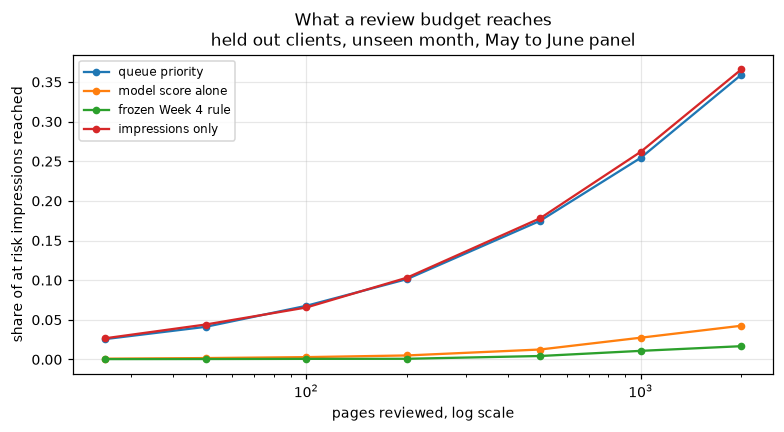

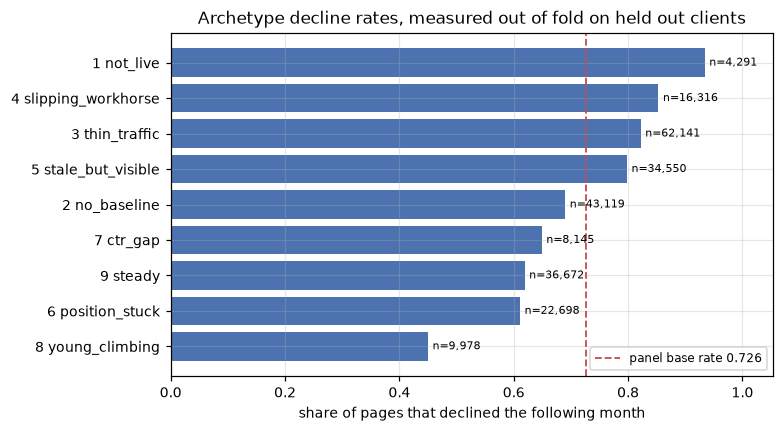

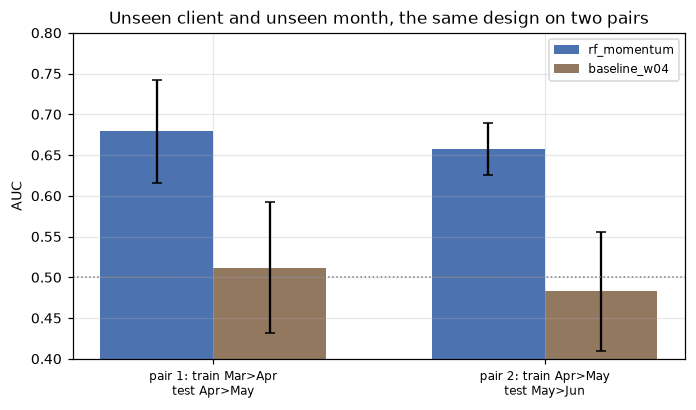

WROTE
  work/outputs/w07_action_queue.csv                        29390.3 KB
  work/outputs/w07_action_playbook_metrics.json               19.4 KB
  work/figures/w07_priority_curve.png                         51.9 KB
  work/figures/w07_archetype_rates.png                        44.0 KB
  work/figures/w07_forward_stability.png                      27.0 KB

queue: 82,877 rows, 47 clients, 27 columns, all
identifiers are warehouse pseudonyms. The CSV is ignored by git on purpose; the JSON and the
three figures are the committed receipts the paper cites.


In [9]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})

# Figure 1. What a review budget reaches.
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for nm in ORDERS:
    d = val[val["order"] == nm]
    ax.plot(d["pages_reviewed"], d["share_of_at_risk_reached"], marker="o", ms=4, label=nm)
ax.set_xscale("log")
ax.set_xlabel("pages reviewed, log scale")
ax.set_ylabel("share of at risk impressions reached")
ax.set_title("What a review budget reaches\nheld out clients, unseen month, May to June panel")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout(); fig.savefig(os.path.join(FIG, "w07_priority_curve.png")); plt.show()

# Figure 2. Measured decline rate by archetype.
fig, ax = plt.subplots(figsize=(7.2, 4.0))
t = tab.sort_values("decline_rate")
ax.barh(t.index.astype(str), t["decline_rate"], color="#4C72B0")
ax.axvline(base3, color="#C44E52", ls="--", lw=1.2, label=f"panel base rate {base3:.3f}")
for i, (nm, r) in enumerate(t.iterrows()):
    ax.text(r["decline_rate"] + 0.008, i, f"n={int(r['pages']):,}", va="center", fontsize=7.5)
ax.set_xlabel("share of pages that declined the following month")
ax.set_title("Archetype decline rates, measured out of fold on held out clients")
ax.set_xlim(0, max(0.9, float(t["decline_rate"].max()) + 0.12)); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(os.path.join(FIG, "w07_archetype_rates.png")); plt.show()

# Figure 3. The same design run twice, one month apart.
fig, ax = plt.subplots(figsize=(6.4, 3.8))
pairs = list(fmean.index.get_level_values("pair").unique())
xs = np.arange(len(pairs))
for i, (mdl, col) in enumerate((("rf_momentum", "#4C72B0"), ("baseline_w04", "#937860"))):
    m = [fmean.loc[(p, mdl), "AUC"] for p in pairs]
    e = [0 if pd.isna(fstd.loc[(p, mdl), "AUC"]) else fstd.loc[(p, mdl), "AUC"] for p in pairs]
    ax.bar(xs + (i - 0.5) * 0.34, m, 0.34, yerr=e, capsize=3, label=mdl, color=col)
ax.axhline(0.5, color="grey", ls=":", lw=1)
ax.set_xticks(xs); ax.set_xticklabels([p.replace(", ", "\n") for p in pairs], fontsize=8)
ax.set_ylabel("AUC"); ax.set_ylim(0.4, 0.8)
ax.set_title("Unseen client and unseen month, the same design on two pairs")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(os.path.join(FIG, "w07_forward_stability.png")); plt.show()

# The queue export.
QCOLS = ["content_hash_id", "client_hash_id", "decision_month", "archetype", "action", "reason_code",
         "rank_in_client", "rank_global", "priority", "p_decline", "impr", "clicks", "ctr",
         "avg_position", "age_days", "mom_impr", "h1_impr", "h2_impr", "days_with_impr",
         "content_type", "main_intent", "word_count", "search_volume", "cpc", "has_market_data",
         "review_required", "scored_by"]
q = queue.copy()
q["decision_month"]   = "2026-06"
q["has_market_data"]  = (q["cpc"].fillna(0) > 0) | (q["search_volume"].fillna(0) > 0)
q["review_required"]  = True
q["scored_by"]        = "rf_momentum trained on 2026-05 features and a 2026-06 label"
q = q[QCOLS].sort_values(["client_hash_id", "rank_in_client"])

# Nothing leaves this notebook that was not meant to. Columns are checked against the allowlist and
# every text column is checked for anything that looks like a name or an address.
assert list(q.columns) == QCOLS, "queue columns drifted from the allowlist"
TEXTCOLS = ["content_hash_id", "client_hash_id", "decision_month", "archetype", "action",
            "reason_code", "content_type", "main_intent", "scored_by"]
for c in TEXTCOLS:
    s = q[c].astype(str)
    assert not s.str.contains("http", case=False).any(), f"{c} carries a URL"
    assert not s.str.contains("@").any(), f"{c} carries an address"

qpath = os.path.join(OUT, "w07_action_queue.csv")
q.to_csv(qpath, index=False)

def _plain(o):
    return o.item() if hasattr(o, "item") else str(o)

metrics = {
    "task": "ML-10 w07_action_playbook",
    "lane": "Refresh / Content Opportunity Scoring",
    "decision_month": "2026-06",
    "model": {"spec": "RandomForestClassifier(n_estimators=200, min_samples_leaf=100, random_state=42)",
              "features": FEATS, "trained_on": "P3, 2026-05 features and a 2026-06 label",
              "label": "next month impressions below 0.8 x this month impressions",
              "calibrated": False, "score_use": "ranking only, never a threshold"},
    "panels": panels.to_dict("records"),
    "forward_tests_mean": fmean.reset_index().to_dict("records"),
    "forward_tests_std": fstd.reset_index().to_dict("records"),
    "archetype_definitions": [
        {"archetype": a, "action": act, "reason_code": rsn, "condition": cond}
        for (a, act, rsn, _), cond in zip(ARCH, [
            "is_published is false or is_deleted is true",
            "first half impressions equal zero",
            f"impressions below {TRAFFIC_FLOOR}",
            f"impressions at least {BIG_TRAFFIC} and mom_impr below {MOM_FALL}",
            f"age at least {AGE_LINE} days and mom_impr below 1.0",
            f"average position between {POS_LO} and {POS_HI}",
            f"average position at most 10 and ctr below {CTR_FLOOR:.2f} percent",
            f"age below {AGE_LINE} days and mom_impr at least 1.0",
            "no earlier condition matched"])],
    "archetype_evaluation": "first match wins in the listed order, so a later condition inherits "
                            "every earlier exclusion, including the 50 impression floor",
    "archetype_rates_out_of_fold": tab.reset_index().to_dict("records"),
    "archetype_rates_measured_on": "P3, held out clients, base rate " + f"{base3:.4f}",
    "capacity_curve": val.to_dict("records"),
    "drift": drift.to_dict("records"),
    "monitor_triggers": mon.to_dict("records"),
    "queue": {"rows": len(q), "clients": int(q["client_hash_id"].nunique()),
              "share_of_live_pages": round(len(q) / len(LIVE), 4),
              "rows_by_action": queue["action"].value_counts().to_dict(),
              "ranked_by": "priority = p_decline x impressions, ranked inside each client"},
    "assumptions": {"review_minutes_per_page": REVIEW_MINUTES,
                    "review_minutes_source": "assumption, not measured in this data",
                    "value_per_visit": "client specific, deliberately not assumed",
                    "paid_media_equivalent": "clicks x cpc, only for rows carrying a market cpc"},
    "no_go": ["automatic edits or publishing", "automatic deletion, redirects, or noindexing",
              "p_decline quoted as a chance or forecast", "cross client league tables",
              "action below the measurement floor or without a first half baseline",
              "budget or pricing decisions from the priority column",
              "any causal sentence about refreshing", "autopilot on a model older than two months",
              "reruns nobody reads the monitoring table for"],
    "claim_language": ["observed", "measured", "associated with", "directional", "decision support"],
    "exports": {"queue_csv": "work/outputs/w07_action_queue.csv (gitignored, regenerated by this run)",
                "metrics_json": "work/outputs/w07_action_playbook_metrics.json",
                "figures": ["work/figures/w07_priority_curve.png",
                            "work/figures/w07_archetype_rates.png",
                            "work/figures/w07_forward_stability.png"]},
}
mpath = os.path.join(OUT, "w07_action_playbook_metrics.json")
with open(mpath, "w") as f:
    json.dump(metrics, f, indent=2, default=_plain)

print("WROTE")
for p in (qpath, mpath, os.path.join(FIG, "w07_priority_curve.png"),
          os.path.join(FIG, "w07_archetype_rates.png"), os.path.join(FIG, "w07_forward_stability.png")):
    print(f"  {os.path.relpath(p, ROOT):55s} {os.path.getsize(p) / 1024:8.1f} KB")
print(f"\nqueue: {len(q):,} rows, {q['client_hash_id'].nunique()} clients, {len(QCOLS)} columns, all")
print("identifiers are warehouse pseudonyms. The CSV is ignored by git on purpose; the JSON and the")
print("three figures are the committed receipts the paper cites.")

## Self-check

- [x] Every section above is filled, markdown thinking and the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime, then Run all)
- [x] No client names, URLs, or private queries anywhere. Identifiers are warehouse pseudonyms, and the
      export cell asserts the column allowlist rather than relying on my memory
- [x] My claims use careful words: observed, measured, directional, decision support. The one claim
      that could not survive the Week 6 audit, decline persisting month over month, is withdrawn in
      section 1 rather than softened
- [x] Committed to my repo under `work/notebooks/`, with the queue, the metrics JSON, and the three
      figures written to `work/outputs/` and `work/figures/`

What a reader should hold onto, and what they should not:

**Carries weight.** Two independent forward tests on unseen clients in unseen months, ranking the same
way. Archetype rates measured out of fold. A capacity curve drawn on rows the model never trained on,
including the part of it that does not flatter the model. A queue that excludes the two populations
Week 6 showed it cannot speak about.

**Does not carry weight.** Any statement about what refreshing does. Any probability read off
`p_decline`. Any comparison of one client against another. Anything about a month more than one step
ahead. Any claim that the queue reaches more at risk traffic than a plain sort by impressions, which
section 3 measured and it does not. Three month pairs is a thin base for a seasonal business, and it is
the first thing I would extend with more data.